# 遮蔽对角线自监督ViT - 损害代理图生成 (12×12矩阵)

## 概述

本notebook实现了基于Vision Transformer的自监督学习方法，用于SAR相干性矩阵的损害评估：

1. **自监督策略**：遮蔽对角线元素，让模型学会从矩阵整体信息预测被遮蔽的值
2. **高斯分布预测**：模型输出 `(mean, std)` 而非单一值，量化预测不确定性
3. **Z-score损害评分**：基于标准化偏差计算损害程度

## 数据格式

- 输入矩阵：`(H, W, 12, 12)` - 每个像素一个12×12相干性矩阵
- 同震数据：`(H, W)` - 同震相邻相干性值（对角线第12个元素，即d₁₂）

## 核心思想

```
矩阵结构 (12×12):
对角线 = [d₀, d₁, d₂, ..., d₁₀, d₁₁] = 相邻时间相干性序列

训练时: 遮蔽对角线元素 → 预测被遮蔽的值
推理时: 用完整矩阵 → 预测下一个对角线元素 d₁₂ (同震相干性)
```

## 1. 环境设置

In [ ]:
# 安装依赖包（首次运行时取消注释）
# !pip install torch torchvision
# !pip install einops
# !pip install matplotlib numpy scipy tqdm
# !pip install psutil

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from tqdm import tqdm
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

from einops import rearrange, repeat
from einops.layers.torch import Rearrange

import os
import gc
import json
import psutil
from datetime import datetime
from pathlib import Path

# 设置随机种子
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# 设置matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# 检查设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")
if device.type == 'cuda':
    print(f"GPU型号: {torch.cuda.get_device_name(0)}")
    print(f"GPU内存: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

def check_memory_usage():
    """检查内存使用情况"""
    process = psutil.Process(os.getpid())
    memory_info = process.memory_info()
    memory_gb = memory_info.rss / 1024 / 1024 / 1024
    print(f"当前内存使用: {memory_gb:.2f} GB")
    
    if torch.cuda.is_available():
        gpu_memory = torch.cuda.memory_allocated() / 1024**3
        print(f"GPU内存使用: {gpu_memory:.2f} GB")
    
    return memory_gb

check_memory_usage()

使用设备: cuda
GPU型号: NVIDIA A40
GPU内存: 47.70 GB
当前内存使用: 0.57 GB
GPU内存使用: 0.00 GB


0.5674591064453125

## 2. 配置参数

In [2]:
# 配置参数
config = {
    # 数据路径 (请根据实际情况修改)
    'matrix_path': '/scratch/yangyanchen/amatrice2025/yunjun/20160821_20160914_matrix.npy',  # (H, W, 12, 12)
    'coseismic_path': '/scratch/yangyanchen/amatrice2025/yunjun/20160821_20160914_label.npy',  # (H, W) 同震相邻相干性
    
    # 矩阵尺寸
    'matrix_size': 12,  # 12×12矩阵
    
    # 数据配置
    'transform': 'logit_squared',  # 'none', 'logit', 'logit_squared'
    'mask_positions': [7, 8, 9, 10, 11],  # 遮蔽对角线的哪些位置 (后5个)
    'mask_value': 0.0,  # 遮蔽位置填充的值
    'add_mask_channel': True,  # 是否添加mask通道
    'val_split': 0.3,  # 验证集比例
    
    # 模型配置
    'image_size': 12,
    'patch_size': 3,  # 12 = 3 × 4
    'in_channels': 2,  # 矩阵通道 + mask通道
    'dim': 128,
    'depth': 6,
    'heads': 8,
    'mlp_dim': 256,
    'dropout': 0.1,
    'dim_head': 64,
    
    # 训练配置
    'batch_size': 256,
    'num_epochs': 50,
    'learning_rate': 1e-4,
    'weight_decay': 1e-5,
    'patience': 10,  # 早停耐心
    'max_grad_norm': 1.0,  # 梯度裁剪
    
    # 预测配置
    'prediction_batch_size': 1024,
    
    # 输出配置
    'output_dir': './masked_diagonal_vit_12x12_results',
    'model_save_path': './masked_diagonal_vit_12x12_best.pth'
}

# 如果不添加mask通道，则输入通道数为1
if not config['add_mask_channel']:
    config['in_channels'] = 1

# 创建输出目录
Path(config['output_dir']).mkdir(exist_ok=True)

print("配置参数:")
print("="*60)
for key, value in config.items():
    print(f"  {key}: {value}")
print("="*60)

配置参数:
  matrix_path: /scratch/yangyanchen/amatrice2025/yunjun/20160821_20160914_matrix.npy
  coseismic_path: /scratch/yangyanchen/amatrice2025/yunjun/20160821_20160914_label.npy
  matrix_size: 12
  transform: logit_squared
  mask_positions: [7, 8, 9, 10, 11]
  mask_value: 0.0
  add_mask_channel: True
  val_split: 0.3
  image_size: 12
  patch_size: 3
  in_channels: 2
  dim: 128
  depth: 6
  heads: 8
  mlp_dim: 256
  dropout: 0.1
  dim_head: 64
  batch_size: 256
  num_epochs: 50
  learning_rate: 0.0001
  weight_decay: 1e-05
  patience: 10
  max_grad_norm: 1.0
  prediction_batch_size: 1024
  output_dir: ./masked_diagonal_vit_12x12_results
  model_save_path: ./masked_diagonal_vit_12x12_best.pth


## 3. 数据集定义

### 3.1 遮蔽对角线自监督数据集

In [3]:
class MaskedDiagonalDataset(Dataset):
    """
    遮蔽对角线自监督数据集 (12×12矩阵)
    
    自监督策略:
    - 从单个矩阵生成多个训练样本
    - 遮蔽对角线的第k个元素
    - 让模型预测被遮蔽的值
    
    这样模型学会: 从矩阵整体信息推断对角线元素
    推理时: 用完整矩阵预测"下一个"对角线元素 (d₁₂)
    """
    
    def __init__(self, matrices, matrix_size=12, mask_positions=None, 
                 transform='none', mask_value=0.0, add_mask_channel=True):
        """
        Parameters:
        - matrices: (N, 12, 12) 或 (H, W, 12, 12) 相干性矩阵
        - matrix_size: 矩阵尺寸 (12)
        - mask_positions: 要遮蔽的对角线位置列表
        - transform: 数据变换 ('none', 'logit', 'logit_squared')
        - mask_value: 遮蔽位置填充的值
        - add_mask_channel: 是否添加mask通道指示遮蔽位置
        """
        self.matrix_size = matrix_size
        
        # 展平为 (N, matrix_size, matrix_size)
        if matrices.ndim == 4:
            H, W = matrices.shape[:2]
            self.original_shape = (H, W)
            matrices = matrices.reshape(-1, matrix_size, matrix_size)
        else:
            self.original_shape = None
        
        self.raw_matrices = matrices.astype(np.float32)
        self.transform = transform
        self.mask_value = mask_value
        self.add_mask_channel = add_mask_channel
        
        # 应用变换
        self.matrices = self._apply_transform(self.raw_matrices.copy())
        
        # 计算变换后的mask_value
        if transform != 'none':
            self.transformed_mask_value = self._apply_transform(
                np.array([[[0.5]]])
            )[0, 0, 0]
        else:
            self.transformed_mask_value = mask_value
        
        # 设置遮蔽位置 (对于12×12，默认遮蔽后5个: 7,8,9,10,11)
        if mask_positions is None:
            self.mask_positions = [7, 8, 9, 10, 11]
        else:
            self.mask_positions = mask_positions
        
        self.num_matrices = len(self.matrices)
        self.num_mask_positions = len(self.mask_positions)
        self.total_samples = self.num_matrices * self.num_mask_positions
        
        self._print_info()
    
    def _apply_transform(self, data):
        """应用数据变换"""
        if self.transform == 'none':
            return data
        
        # 裁剪避免边界问题
        data = np.clip(data, 1e-6, 1 - 1e-6)
        
        if self.transform == 'logit':
            return np.log(data / (1 - data))
        elif self.transform == 'logit_squared':
            return np.log(data**2 / (1 - data**2))
        return data
    
    def _print_info(self):
        """打印数据集信息"""
        print(f"\n{'='*60}")
        print(f"遮蔽对角线自监督数据集 ({self.matrix_size}×{self.matrix_size})")
        print(f"{'='*60}")
        print(f"  原始矩阵数量: {self.num_matrices:,}")
        print(f"  矩阵尺寸: {self.matrix_size}×{self.matrix_size}")
        print(f"  遮蔽位置: {self.mask_positions}")
        print(f"  每个矩阵生成样本数: {self.num_mask_positions}")
        print(f"  总训练样本数: {self.total_samples:,}")
        print(f"  数据变换: {self.transform}")
        print(f"  添加mask通道: {self.add_mask_channel}")
        
        # 检查对角线统计
        diagonals = np.array([np.diag(m) for m in self.matrices])
        print(f"  变换后对角线值范围: [{diagonals.min():.4f}, {diagonals.max():.4f}]")
        print(f"  变换后对角线均值: {diagonals.mean():.4f}")
        print(f"{'='*60}\n")
    
    def __len__(self):
        return self.total_samples
    
    def __getitem__(self, idx):
        # 计算矩阵索引和遮蔽位置
        matrix_idx = idx // self.num_mask_positions
        mask_pos_idx = idx % self.num_mask_positions
        mask_pos = self.mask_positions[mask_pos_idx]
        
        # 获取矩阵
        matrix = self.matrices[matrix_idx].copy()
        
        # 获取标签 (被遮蔽位置的真实值)
        label = matrix[mask_pos, mask_pos]  # 对角线元素
        
        # 创建遮蔽矩阵
        masked_matrix = matrix.copy()
        masked_matrix[mask_pos, mask_pos] = self.transformed_mask_value
        
        if self.add_mask_channel:
            # 创建mask通道 (指示哪个位置被遮蔽)
            mask_channel = np.zeros((self.matrix_size, self.matrix_size), dtype=np.float32)
            mask_channel[mask_pos, mask_pos] = 1.0
            
            # 堆叠为2通道: (2, 12, 12)
            input_tensor = torch.FloatTensor(
                np.stack([masked_matrix, mask_channel], axis=0)
            )
        else:
            # 单通道: (1, 12, 12)
            input_tensor = torch.FloatTensor(masked_matrix).unsqueeze(0)
        
        label_tensor = torch.FloatTensor([label])
        
        return input_tensor, label_tensor

### 3.2 加载数据

In [4]:
print("加载数据...")
print("="*60)

matrix_size = config['matrix_size']

# 加载相干性矩阵
try:
    matrices = np.load(config['matrix_path'])
    print(f"加载矩阵数据: {config['matrix_path']}")
    print(f"  形状: {matrices.shape}")
except FileNotFoundError:
    print(f"警告: 未找到数据文件 {config['matrix_path']}")
    print("使用模拟数据进行演示...")
    
    # 创建模拟数据 (12×12矩阵)
    H, W = 200, 200  # 图像尺寸
    matrices = np.random.rand(H, W, matrix_size, matrix_size).astype(np.float32) * 0.7 + 0.15
    
    # 确保对称性
    for i in range(H):
        for j in range(W):
            matrices[i, j] = (matrices[i, j] + matrices[i, j].T) / 2
    
    print(f"  模拟矩阵形状: {matrices.shape}")

# 加载同震数据
try:
    coseismic_values = np.load(config['coseismic_path'])
    print(f"\n加载同震数据: {config['coseismic_path']}")
    print(f"  形状: {coseismic_values.shape}")
except FileNotFoundError:
    print(f"\n警告: 未找到同震数据文件 {config['coseismic_path']}")
    print("使用模拟同震数据...")
    
    # 模拟同震数据 (相干性下降)
    H, W = matrices.shape[:2]
    coseismic_values = np.random.rand(H, W).astype(np.float32) * 0.4 + 0.1
    print(f"  模拟同震数据形状: {coseismic_values.shape}")

# 记录原始形状
original_shape = matrices.shape[:2]
print(f"\n图像尺寸: {original_shape}")
print(f"矩阵尺寸: {matrix_size}×{matrix_size}")
print(f"总像素数: {np.prod(original_shape):,}")

check_memory_usage()
print("="*60)

加载数据...
加载矩阵数据: /scratch/yangyanchen/amatrice2025/yunjun/20160821_20160914_matrix.npy
  形状: (990, 5400, 12, 12)

加载同震数据: /scratch/yangyanchen/amatrice2025/yunjun/20160821_20160914_label.npy
  形状: (990, 5400)

图像尺寸: (990, 5400)
矩阵尺寸: 12×12
总像素数: 5,346,000
当前内存使用: 3.46 GB
GPU内存使用: 0.00 GB


### 3.2.1 分层抽样 (Stratified Sampling)

为了加速训练，采用分层抽样策略：
1. 保留所有相干性 > 0.45 的样本（高相干性样本）
2. 从其他区间采样相同数量的样本（分层抽样）

分层抽样 (Stratified Sampling)
原始样本总数: 5,346,000

相干性分布:
  高相干性 (>0.3): 3,552,158 样本 (66.45%)
  低相干性 (≤0.3): 1,793,842 样本 (33.55%)

警告: 低相干性样本数量 (1793842) 少于高相干性样本数量 (3552158)
  将保留所有低相干性样本

采样结果:
  高相干性样本: 3,552,158
  采样的低相干性样本: 1,793,842
  总采样数: 5,346,000
  采样比例: 100.00%

采样后数据形状:
  matrices: (5346000, 12, 12)
  coseismic: (5346000,)

采样后相干性分布验证:
  高相干性: 3,552,158 (66.45%)
  低相干性: 1,793,842 (33.55%)


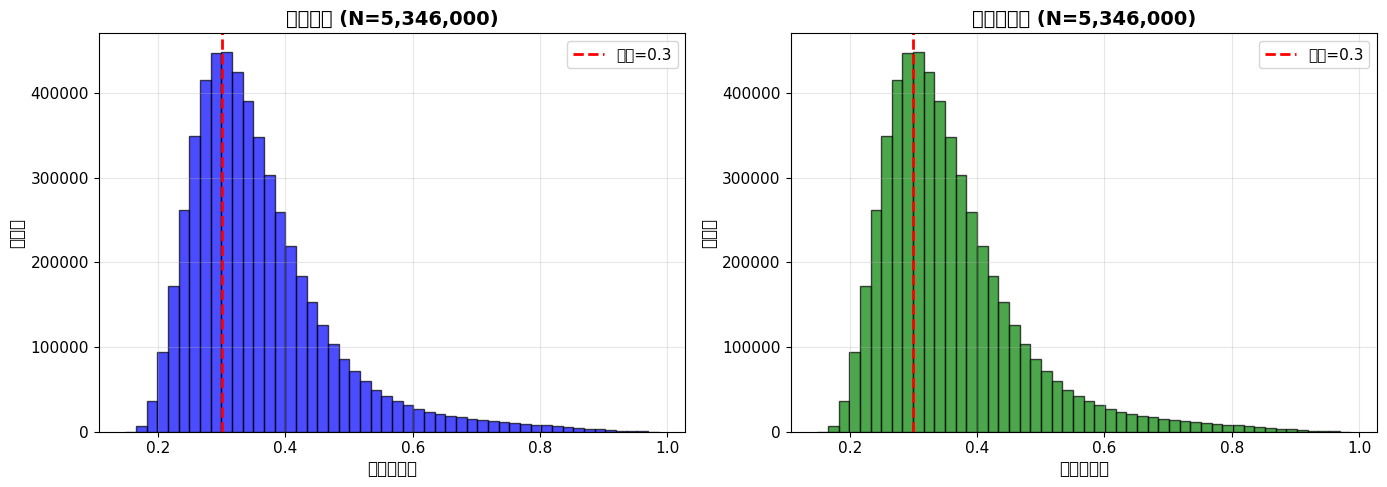


采样信息已保存到: ./masked_diagonal_vit_12x12_results/sampling_info.json
当前内存使用: 6.46 GB
GPU内存使用: 0.00 GB


In [5]:
print("="*60)
print("分层抽样 (Stratified Sampling)")
print("="*60)

# 设置相干性阈值
COHERENCE_THRESHOLD = 0.3

# 展平数据以便处理
H, W = matrices.shape[:2]
matrices_flat = matrices.reshape(-1, matrix_size, matrix_size)  # (N, 12, 12)
coseismic_flat = coseismic_values.flatten()  # (N,)

print(f"原始样本总数: {len(coseismic_flat):,}")

# 找出高相干性样本 (coseismic > 0.45)
high_coherence_mask = coseismic_flat > COHERENCE_THRESHOLD
high_coherence_indices = np.where(high_coherence_mask)[0]
low_coherence_indices = np.where(~high_coherence_mask)[0]

n_high = len(high_coherence_indices)
n_low = len(low_coherence_indices)

print(f"\n相干性分布:")
print(f"  高相干性 (>{COHERENCE_THRESHOLD}): {n_high:,} 样本 ({n_high/len(coseismic_flat)*100:.2f}%)")
print(f"  低相干性 (≤{COHERENCE_THRESHOLD}): {n_low:,} 样本 ({n_low/len(coseismic_flat)*100:.2f}%)")

# 分层抽样策略：
# 1. 保留所有高相干性样本
# 2. 从低相干性样本中随机抽取与高相干性相同数量的样本

# 设置随机种子确保可重复性
np.random.seed(SEED)

# 从低相干性样本中进行分层抽样
if n_low >= n_high:
    # 如果低相干性样本足够，随机抽取n_high个
    sampled_low_indices = np.random.choice(low_coherence_indices, size=n_high, replace=False)
else:
    # 如果低相干性样本不够，全部保留
    sampled_low_indices = low_coherence_indices
    print(f"\n警告: 低相干性样本数量 ({n_low}) 少于高相干性样本数量 ({n_high})")
    print("  将保留所有低相干性样本")

# 合并采样索引
sampled_indices = np.concatenate([high_coherence_indices, sampled_low_indices])
sampled_indices = np.sort(sampled_indices)  # 排序以保持空间一致性

print(f"\n采样结果:")
print(f"  高相干性样本: {len(high_coherence_indices):,}")
print(f"  采样的低相干性样本: {len(sampled_low_indices):,}")
print(f"  总采样数: {len(sampled_indices):,}")
print(f"  采样比例: {len(sampled_indices)/len(coseismic_flat)*100:.2f}%")

# 提取采样后的数据
matrices_sampled = matrices_flat[sampled_indices]
coseismic_sampled = coseismic_flat[sampled_indices]

print(f"\n采样后数据形状:")
print(f"  matrices: {matrices_sampled.shape}")
print(f"  coseismic: {coseismic_sampled.shape}")

# 验证采样分布
sampled_high = np.sum(coseismic_sampled > COHERENCE_THRESHOLD)
sampled_low = np.sum(coseismic_sampled <= COHERENCE_THRESHOLD)
print(f"\n采样后相干性分布验证:")
print(f"  高相干性: {sampled_high:,} ({sampled_high/len(coseismic_sampled)*100:.2f}%)")
print(f"  低相干性: {sampled_low:,} ({sampled_low/len(coseismic_sampled)*100:.2f}%)")

# 可视化采样前后的相干性分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 原始分布
axes[0].hist(coseismic_flat, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(COHERENCE_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'阈值={COHERENCE_THRESHOLD}')
axes[0].set_xlabel('同震相干性', fontsize=12)
axes[0].set_ylabel('样本数', fontsize=12)
axes[0].set_title(f'原始分布 (N={len(coseismic_flat):,})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 采样后分布
axes[1].hist(coseismic_sampled, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(COHERENCE_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'阈值={COHERENCE_THRESHOLD}')
axes[1].set_xlabel('同震相干性', fontsize=12)
axes[1].set_ylabel('样本数', fontsize=12)
axes[1].set_title(f'采样后分布 (N={len(coseismic_sampled):,})', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config['output_dir']}/stratified_sampling_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# 保存采样索引以便后续使用
sampling_info = {
    'threshold': COHERENCE_THRESHOLD,
    'n_original': len(coseismic_flat),
    'n_sampled': len(sampled_indices),
    'n_high_coherence': len(high_coherence_indices),
    'n_low_coherence_sampled': len(sampled_low_indices)
}

# 保存采样信息
with open(f"{config['output_dir']}/sampling_info.json", 'w') as f:
    json.dump(sampling_info, f, indent=2)
    print(f"\n采样信息已保存到: {config['output_dir']}/sampling_info.json")

check_memory_usage()
print("="*60)

### 3.3 创建数据集和DataLoader

In [6]:
print("创建数据集...")

# 使用采样后的数据创建数据集
# 注意：matrices_sampled 已经是 (N_sampled, 12, 12) 形状
full_dataset = MaskedDiagonalDataset(
    matrices=matrices_sampled,  # 使用采样后的矩阵
    matrix_size=config['matrix_size'],
    mask_positions=config['mask_positions'],
    transform=config['transform'],
    mask_value=config['mask_value'],
    add_mask_channel=config['add_mask_channel']
)

# 划分训练/验证集
val_size = int(len(full_dataset) * config['val_split'])
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"\n数据划分:")
print(f"  训练集: {len(train_dataset):,} 样本")
print(f"  验证集: {len(val_dataset):,} 样本")

# 创建DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

# 测试数据加载
print("\n测试数据加载...")
sample_input, sample_label = next(iter(train_loader))
print(f"  输入形状: {sample_input.shape}")
print(f"  标签形状: {sample_label.shape}")
print(f"  标签范围: [{sample_label.min():.4f}, {sample_label.max():.4f}]")

创建数据集...



遮蔽对角线自监督数据集 (12×12)
  原始矩阵数量: 5,346,000
  矩阵尺寸: 12×12
  遮蔽位置: [7, 8, 9, 10, 11]
  每个矩阵生成样本数: 5
  总训练样本数: 26,730,000
  数据变换: logit_squared
  添加mask通道: True
  变换后对角线值范围: [-3.8167, 6.0811]
  变换后对角线均值: -1.9939


数据划分:
  训练集: 18,711,000 样本
  验证集: 8,019,000 样本

测试数据加载...
  输入形状: torch.Size([256, 2, 12, 12])
  标签形状: torch.Size([256, 1])
  标签范围: [-3.2931, 2.2644]


### 3.4 可视化样本数据

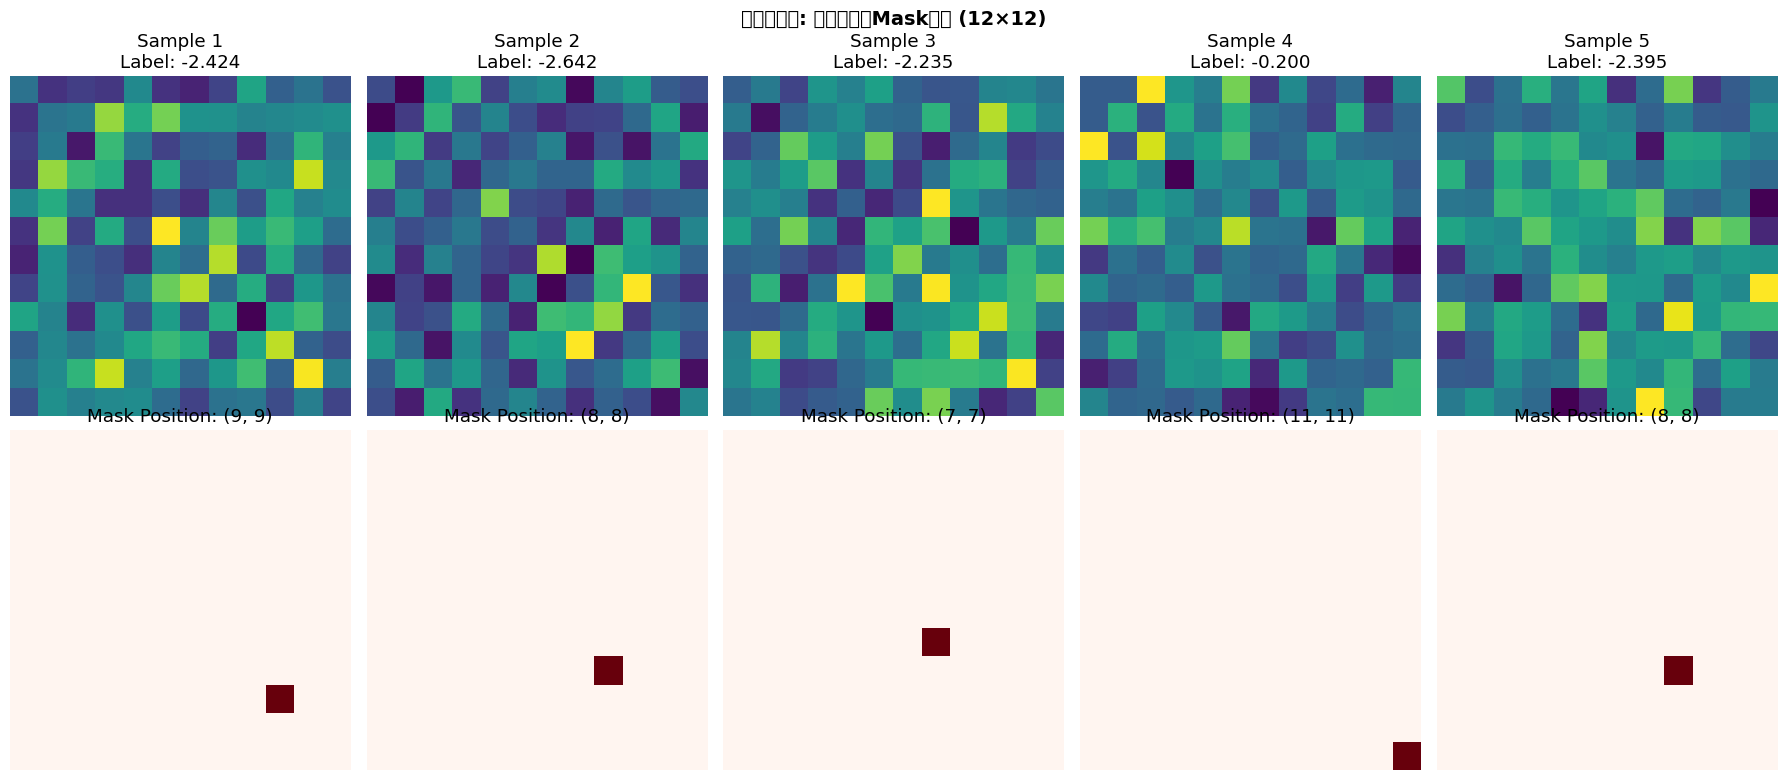

In [7]:
# 可视化样本
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i in range(5):
    # 显示遮蔽后的矩阵
    matrix_channel = sample_input[i, 0].cpu().numpy()
    im1 = axes[0, i].imshow(matrix_channel, cmap='viridis')
    axes[0, i].set_title(f'Sample {i+1}\nLabel: {sample_label[i].item():.3f}')
    axes[0, i].axis('off')
    
    # 显示mask通道
    if config['add_mask_channel']:
        mask_channel = sample_input[i, 1].cpu().numpy()
        im2 = axes[1, i].imshow(mask_channel, cmap='Reds')
        # 找到遮蔽位置
        mask_pos = np.where(mask_channel > 0)
        if len(mask_pos[0]) > 0:
            axes[1, i].set_title(f'Mask Position: ({mask_pos[0][0]}, {mask_pos[1][0]})')
        axes[1, i].axis('off')

axes[0, 0].set_ylabel('Masked Matrix (12×12)', fontsize=12)
axes[1, 0].set_ylabel('Mask Channel', fontsize=12)

plt.suptitle('样本可视化: 遮蔽矩阵与Mask通道 (12×12)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{config['output_dir']}/sample_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. 模型定义

### 4.1 注意力机制和Transformer块

In [8]:
class Attention(nn.Module):
    """多头自注意力机制"""
    
    def __init__(self, dim, heads=8, dim_head=64, dropout=0.):
        super().__init__()
        inner_dim = dim_head * heads
        self.heads = heads
        self.scale = dim_head ** -0.5
        
        self.attend = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(dropout)
        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias=False)
        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h=self.heads), qkv)
        
        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        attn = self.attend(dots)
        attn = self.dropout(attn)
        
        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)


class FeedForward(nn.Module):
    """前馈网络"""
    
    def __init__(self, dim, hidden_dim, dropout=0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    """Transformer编码器块"""
    
    def __init__(self, dim, heads, dim_head, mlp_dim, dropout=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, heads=heads, dim_head=dim_head, dropout=dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.ff = FeedForward(dim, mlp_dim, dropout=dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x

### 4.2 遮蔽对角线预测ViT模型 (12×12)

In [9]:
class MaskedDiagonalViT(nn.Module):
    """
    遮蔽对角线预测Vision Transformer (12×12矩阵)
    
    输入: 遮蔽后的相干性矩阵 (+ 可选的mask通道)
    输出: (μ, σ) 预测被遮蔽/下一个对角线元素的高斯分布参数
    
    核心思想:
    - 训练时: 预测被遮蔽的对角线元素
    - 推理时: 预测矩阵外的下一个对角线元素 (d₁₂)
    """
    
    def __init__(
        self,
        image_size=12,
        patch_size=3,  # 12 = 3 × 4 patches
        in_channels=2,
        dim=128,
        depth=6,
        heads=8,
        mlp_dim=256,
        dropout=0.1,
        dim_head=64
    ):
        super().__init__()
        
        assert image_size % patch_size == 0, \
            f"Image size {image_size} must be divisible by patch size {patch_size}"
        
        num_patches = (image_size // patch_size) ** 2  # 16 patches for 12×12 with patch_size=3
        patch_dim = in_channels * patch_size * patch_size
        
        self.image_size = image_size
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.num_patches = num_patches
        
        # Patch embedding
        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=patch_size, p2=patch_size),
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, dim),
            nn.LayerNorm(dim)
        )
        
        # Position embedding & CLS token
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout_layer = nn.Dropout(dropout)
        
        # Transformer encoder
        self.transformer = nn.ModuleList([
            TransformerBlock(dim, heads, dim_head, mlp_dim, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(dim)
        
        # 输出头: 预测 (mean, std)
        self.mean_head = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim // 2, 1)
        )
        
        self.log_std_head = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim // 2, 1)
        )
        
        self._initialize_weights()
        self._print_info()
    
    def _initialize_weights(self):
        """权重初始化"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
    
    def _print_info(self):
        """打印模型信息"""
        print(f"\n{'='*60}")
        print(f"MaskedDiagonalViT 模型配置 (12×12)")
        print(f"{'='*60}")
        print(f"  输入尺寸: {self.image_size}×{self.image_size}")
        print(f"  输入通道: {self.in_channels}")
        print(f"  Patch尺寸: {self.patch_size}×{self.patch_size}")
        print(f"  Patch数量: {self.num_patches} ({self.image_size//self.patch_size}×{self.image_size//self.patch_size})")
        print(f"  总参数量: {self.count_parameters():,}")
        print(f"{'='*60}\n")
    
    def count_parameters(self):
        """计算参数数量"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)
    
    def forward(self, x):
        """
        前向传播
        
        输入: x (batch, channels, 12, 12)
        输出: mean (batch, 1), std (batch, 1)
        """
        # Patch embedding
        x = self.to_patch_embedding(x)
        b, n, _ = x.shape
        
        # Add CLS token
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=b)
        x = torch.cat((cls_tokens, x), dim=1)
        
        # Add position embedding
        x = x + self.pos_embedding[:, :(n + 1)]
        x = self.dropout_layer(x)
        
        # Transformer blocks
        for block in self.transformer:
            x = block(x)
        
        x = self.norm(x)
        
        # Use CLS token for prediction
        cls_feature = x[:, 0]
        
        # Predict mean and std
        mean = self.mean_head(cls_feature)
        log_std = self.log_std_head(cls_feature)
        std = torch.exp(log_std).clamp(min=1e-6, max=2.0)
        
        return mean, std

### 4.3 创建模型

In [10]:
# 创建模型
model = MaskedDiagonalViT(
    image_size=config['image_size'],
    patch_size=config['patch_size'],
    in_channels=config['in_channels'],
    dim=config['dim'],
    depth=config['depth'],
    heads=config['heads'],
    mlp_dim=config['mlp_dim'],
    dropout=config['dropout'],
    dim_head=config['dim_head']
).to(device)

# 测试前向传播
print("测试前向传播...")
test_input = torch.randn(2, config['in_channels'], 12, 12).to(device)
test_mean, test_std = model(test_input)
print(f"  输入: {test_input.shape}")
print(f"  输出mean: {test_mean.shape}")
print(f"  输出std: {test_std.shape}")
print(f"  mean值: {test_mean.squeeze().cpu().detach().numpy()}")
print(f"  std值: {test_std.squeeze().cpu().detach().numpy()}")


MaskedDiagonalViT 模型配置 (12×12)
  输入尺寸: 12×12
  输入通道: 2
  Patch尺寸: 3×3
  Patch数量: 16 (4×4)
  总参数量: 1,994,150

测试前向传播...
  输入: torch.Size([2, 2, 12, 12])
  输出mean: torch.Size([2, 1])
  输出std: torch.Size([2, 1])
  mean值: [ 0.29290044 -0.381137  ]
  std值: [2. 2.]


## 5. 训练模型

### 5.1 损失函数

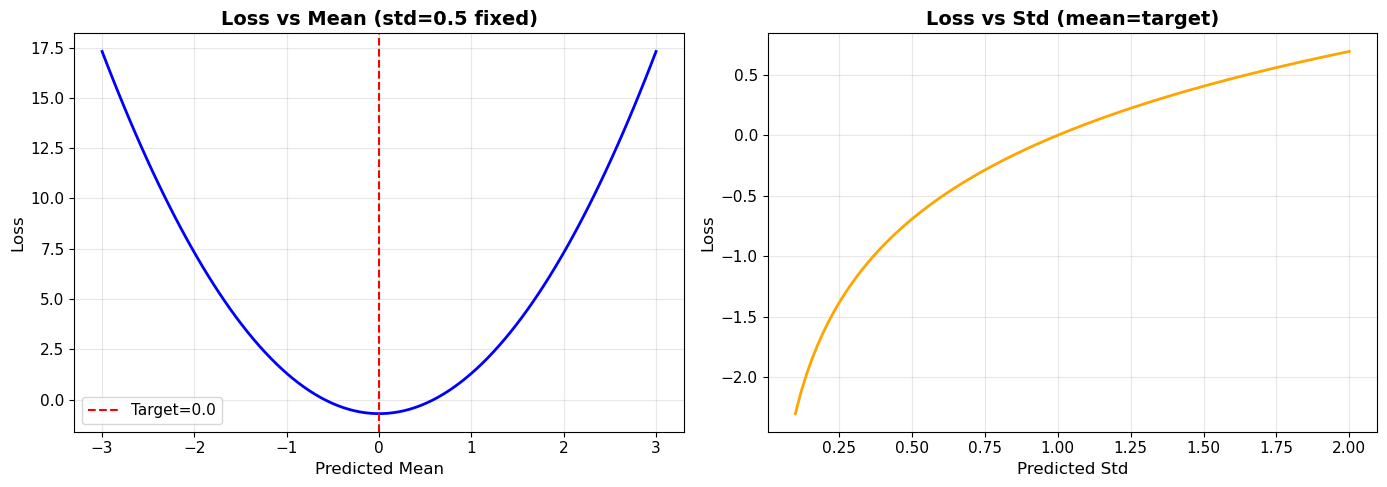

损失函数特性:
  左图: mean偏离target越远，loss越大 → 鼓励准确预测
  右图: std有最优值，过大或过小都会增加loss → 鼓励合理的不确定性估计


In [11]:
def gaussian_nll_loss(pred_mean, pred_std, target):
    """
    高斯负对数似然损失
    
    假设: target ~ N(pred_mean, pred_std²)
    目标: 最大化观测到target的概率
    
    公式: loss = ½log(σ²) + (y-μ)²/(2σ²)
    
    Parameters:
        pred_mean: (batch, 1) 预测均值
        pred_std: (batch, 1) 预测标准差
        target: (batch, 1) 真实值
    """
    variance = pred_std ** 2 + 1e-8  # 数值稳定性
    loss = 0.5 * torch.log(variance) + 0.5 * ((target - pred_mean) ** 2) / variance
    return loss.mean()


# 可视化损失函数行为
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 固定std，变化mean
target_val = 0.0
mean_vals = np.linspace(-3, 3, 100)
std_fixed = 0.5

losses_mean = []
for m in mean_vals:
    loss = 0.5 * np.log(std_fixed**2) + 0.5 * ((target_val - m)**2) / (std_fixed**2)
    losses_mean.append(loss)

axes[0].plot(mean_vals, losses_mean, linewidth=2, color='blue')
axes[0].axvline(target_val, color='r', linestyle='--', label=f'Target={target_val}')
axes[0].set_xlabel('Predicted Mean', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss vs Mean (std=0.5 fixed)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. 固定mean，变化std
mean_fixed = target_val
std_vals = np.linspace(0.1, 2.0, 100)

losses_std = []
for s in std_vals:
    loss = 0.5 * np.log(s**2) + 0.5 * ((target_val - mean_fixed)**2) / (s**2)
    losses_std.append(loss)

axes[1].plot(std_vals, losses_std, linewidth=2, color='orange')
axes[1].set_xlabel('Predicted Std', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Loss vs Std (mean=target)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config['output_dir']}/loss_function_behavior.png", dpi=150, bbox_inches='tight')
plt.show()

print("损失函数特性:")
print("  左图: mean偏离target越远，loss越大 → 鼓励准确预测")
print("  右图: std有最优值，过大或过小都会增加loss → 鼓励合理的不确定性估计")

### 5.2 训练循环

In [12]:
def train_epoch(model, loader, optimizer, device):
    """训练一个epoch"""
    model.train()
    total_loss = 0
    num_batches = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for inputs, labels in pbar:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # 前向传播
        pred_mean, pred_std = model(inputs)
        
        # 计算损失
        loss = gaussian_nll_loss(pred_mean, pred_std, labels)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config['max_grad_norm'])
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / num_batches


def validate(model, loader, device):
    """验证"""
    model.eval()
    total_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Validation', leave=False):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            pred_mean, pred_std = model(inputs)
            loss = gaussian_nll_loss(pred_mean, pred_std, labels)
            
            total_loss += loss.item()
            num_batches += 1
    
    return total_loss / num_batches

In [ ]:
# 训练配置
optimizer = optim.AdamW(
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay']
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5, verbose=True, min_lr=1e-7
)

# 训练历史
history = {
    'train_loss': [],
    'val_loss': [],
    'lr': []
}

best_val_loss = float('inf')
patience_counter = 0

print(f"\n{'='*60}")
print("开始训练 MaskedDiagonalViT (12×12)")
print(f"{'='*60}")
print(f"  设备: {device}")
print(f"  学习率: {config['learning_rate']}")
print(f"  批次大小: {config['batch_size']}")
print(f"  训练轮数: {config['num_epochs']}")
print(f"  早停耐心: {config['patience']}")
print(f"{'='*60}\n")

# 训练循环
for epoch in range(config['num_epochs']):
    # 训练
    train_loss = train_epoch(model, train_loader, optimizer, device)
    
    # 验证
    val_loss = validate(model, val_loader, device)
    
    # 学习率调整
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # 记录历史
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(current_lr)
    
    # 打印结果
    print(f"Epoch {epoch+1:3d}/{config['num_epochs']} | "
          f"Train Loss: {train_loss:10.6f} | "
          f"Val Loss: {val_loss:10.6f} | "
          f"LR: {current_lr:.2e}")
    
    # 保存最佳模型
    if val_loss < best_val_loss:
        improvement = best_val_loss - val_loss
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'config': config
        }, config['model_save_path'])
        print(f"  💾 保存最佳模型 (提升: {improvement:.6f})")
    else:
        patience_counter += 1
        print(f"  ⏳ 无改善 ({patience_counter}/{config['patience']})")
    
    # 早停
    if patience_counter >= config['patience']:
        print(f"\n🛑 早停: {config['patience']}轮无改善")
        break
    
    # 定期清理内存
    if epoch % 5 == 0:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"训练完成! 最佳验证损失: {best_val_loss:.6f}")
print(f"{'='*60}")


开始训练 MaskedDiagonalViT (12×12)
  设备: cuda
  学习率: 0.0001
  批次大小: 256
  训练轮数: 50
  早停耐心: 10



Epoch   1/50 | Train Loss:  -0.023292 | Val Loss:  -0.051239 | LR: 1.00e-04
  💾 保存最佳模型 (提升: inf)


Epoch   2/50 | Train Loss:  -0.045322 | Val Loss:  -0.058011 | LR: 1.00e-04
  💾 保存最佳模型 (提升: 0.006772)


Epoch   3/50 | Train Loss:  -0.051627 | Val Loss:  -0.061739 | LR: 1.00e-04
  💾 保存最佳模型 (提升: 0.003728)


Epoch   4/50 | Train Loss:  -0.054674 | Val Loss:  -0.061768 | LR: 1.00e-04
  💾 保存最佳模型 (提升: 0.000029)


...

Epoch  12/50 | Train Loss:  -0.061457 | Val Loss:  -0.065573 | LR: 1.00e-04
  💾 保存最佳模型 (提升: 0.000506)


Epoch  13/50 | Train Loss:  -0.061854 | Val Loss:  -0.065941 | LR: 1.00e-04
  💾 保存最佳模型 (提升: 0.000368)


Epoch  14/50 | Train Loss:  -0.062264 | Val Loss:  -0.065019 | LR: 1.00e-04
  ⏳ 无改善 (1/10)


Epoch  15/50 | Train Loss:  -0.062608 | Val Loss:  -0.065537 | LR: 1.00e-04
  ⏳ 无改善 (2/10)


Validation:   4%|▍         | 1356/31325 [00:18<06:36, 75.50it/s]               

### 5.3 训练曲线可视化

NameError: name 'history' is not defined

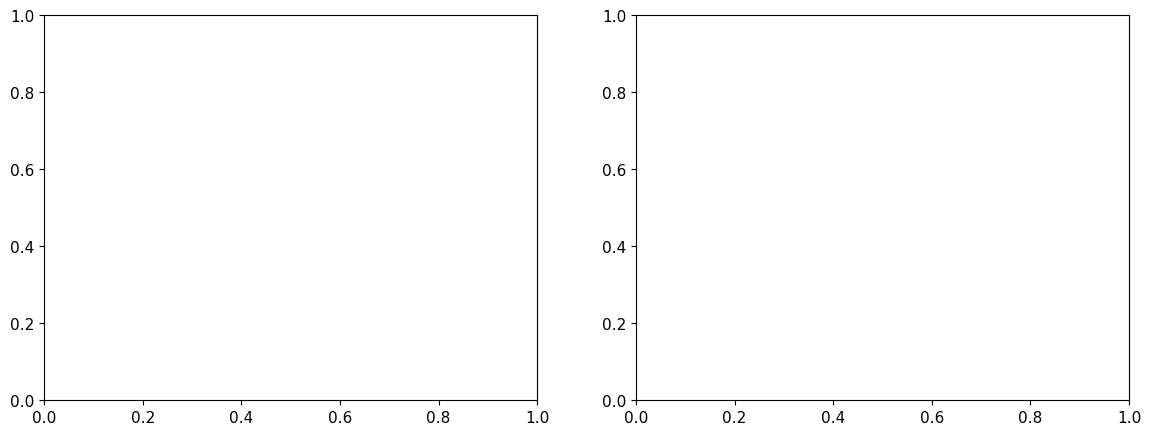

: 

: 

: 

: 

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)

# Loss曲线
axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 学习率曲线
axes[1].plot(epochs, history['lr'], 'g-', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Learning Rate', fontsize=12)
axes[1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config['output_dir']}/training_curves.png", dpi=200, bbox_inches='tight')
plt.show()

print(f"最终训练损失: {history['train_loss'][-1]:.6f}")
print(f"最终验证损失: {history['val_loss'][-1]:.6f}")
print(f"最佳验证损失: {best_val_loss:.6f}")

## 6. 生成Z-score损害图

### 6.1 加载最佳模型

In [13]:
print("加载最佳模型...")
checkpoint = torch.load(config['model_save_path'], map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"  加载模型 (Epoch {checkpoint['epoch']}, Val Loss: {checkpoint['val_loss']:.6f})")
model.eval()

加载最佳模型...


  加载模型 (Epoch 24, Val Loss: -0.067470)


MaskedDiagonalViT(
  (to_patch_embedding): Sequential(
    (0): Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=3, p2=3)
    (1): LayerNorm((18,), eps=1e-05, elementwise_affine=True)
    (2): Linear(in_features=18, out_features=128, bias=True)
    (3): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (dropout_layer): Dropout(p=0.1, inplace=False)
  (transformer): ModuleList(
    (0-5): 6 x TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (attend): Softmax(dim=-1)
        (dropout): Dropout(p=0.1, inplace=False)
        (to_qkv): Linear(in_features=128, out_features=1536, bias=False)
        (to_out): Sequential(
          (0): Linear(in_features=512, out_features=128, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, 

### 6.2 生成预测和Z-score

In [14]:
def generate_zscore_map(model, matrices, coseismic_values, device, config):
    """
    生成Z-score损害图
    
    Parameters:
    - model: 训练好的MaskedDiagonalViT
    - matrices: (H, W, 12, 12) 震前矩阵
    - coseismic_values: (H, W) 同震相邻相干性 (d₁₂)
    - device: 计算设备
    - config: 配置字典
    
    Returns:
    - results: 包含各种输出的字典
    """
    model.eval()
    
    matrix_size = config['matrix_size']
    
    # 记录原始形状
    H, W = matrices.shape[:2]
    matrices_flat = matrices.reshape(-1, matrix_size, matrix_size)
    coseismic_flat = coseismic_values.reshape(-1)
    
    num_samples = len(matrices_flat)
    batch_size = config['prediction_batch_size']
    transform = config['transform']
    add_mask_channel = config['add_mask_channel']
    
    # 应用变换
    if transform == 'logit':
        data = np.clip(matrices_flat, 1e-6, 1 - 1e-6)
        data = np.log(data / (1 - data))
        coseismic_transformed = np.clip(coseismic_flat, 1e-6, 1 - 1e-6)
        coseismic_transformed = np.log(coseismic_transformed / (1 - coseismic_transformed))
    elif transform == 'logit_squared':
        data = np.clip(matrices_flat, 1e-6, 1 - 1e-6)
        data = np.log(data**2 / (1 - data**2))
        coseismic_transformed = np.clip(coseismic_flat, 1e-6, 1 - 1e-6)
        coseismic_transformed = np.log(coseismic_transformed**2 / (1 - coseismic_transformed**2))
    else:
        data = matrices_flat.astype(np.float32)
        coseismic_transformed = coseismic_flat.astype(np.float32)
    
    # 初始化结果数组
    z_scores = np.zeros(num_samples)
    pred_means = np.zeros(num_samples)
    pred_stds = np.zeros(num_samples)
    
    print(f"\n{'='*60}")
    print(f"生成Z-score损害图 (12×12)")
    print(f"{'='*60}")
    print(f"  样本数: {num_samples:,}")
    print(f"  批次大小: {batch_size}")
    print(f"  数据变换: {transform}")
    
    with torch.no_grad():
        for start_idx in tqdm(range(0, num_samples, batch_size), desc="预测中"):
            end_idx = min(start_idx + batch_size, num_samples)
            
            batch_matrices = data[start_idx:end_idx]
            
            if add_mask_channel:
                # 预测时：添加mask通道，标记位置11（预测位置12）
                mask_channel = np.zeros_like(batch_matrices)
                for i in range(len(batch_matrices)):
                    mask_channel[i, matrix_size-1, matrix_size-1] = 1.0  # 位置(11,11)
                
                batch_input = np.stack([batch_matrices, mask_channel], axis=1)
            else:
                batch_input = batch_matrices[:, np.newaxis, :, :]
            
            batch_tensor = torch.FloatTensor(batch_input).to(device)
            
            mean, std = model(batch_tensor)
            mean = mean.cpu().numpy().squeeze()
            std = std.cpu().numpy().squeeze()
            
            # 处理单样本情况
            if mean.ndim == 0:
                mean = np.array([mean])
                std = np.array([std])
            
            # 获取观测值
            observed = coseismic_transformed[start_idx:end_idx]
            
            # 计算Z-score: Z = (预测 - 观测) / std
            z = (mean - observed) / (std + 1e-8)
            
            # 存储结果
            pred_means[start_idx:end_idx] = mean
            pred_stds[start_idx:end_idx] = std
            z_scores[start_idx:end_idx] = z
    
    # 重塑为原始形状
    z_scores = z_scores.reshape(H, W)
    pred_means = pred_means.reshape(H, W)
    pred_stds = pred_stds.reshape(H, W)
    
    # 统计信息
    valid_z = z_scores[np.isfinite(z_scores)]
    print(f"\nZ-score统计:")
    print(f"  均值: {np.mean(valid_z):.4f} (理想值≈0)")
    print(f"  标准差: {np.std(valid_z):.4f} (理想值≈1)")
    print(f"  范围: [{np.min(valid_z):.2f}, {np.max(valid_z):.2f}]")
    
    print(f"\n损害检测 (Z-score阈值):")
    for thresh in [3.0, 4.0, 4.93, 5.0, 6.0]:
        count = np.sum(valid_z > thresh)
        pct = count / len(valid_z) * 100
        print(f"  Z > {thresh}: {count:,} ({pct:.2f}%)")
    print(f"{'='*60}")
    
    return {
        'z_scores': z_scores,
        'pred_means': pred_means,
        'pred_stds': pred_stds,
        'coseismic_observed': coseismic_values
    }

In [15]:
# 生成Z-score
results = generate_zscore_map(model, matrices, coseismic_values, device, config)


生成Z-score损害图 (12×12)
  样本数: 5,346,000
  批次大小: 1024
  数据变换: logit_squared


预测中: 100%|██████████| 5221/5221 [05:24<00:00, 16.08it/s]



Z-score统计:
  均值: 0.6164 (理想值≈0)
  标准差: 0.9672 (理想值≈1)
  范围: [-7.80, 10.19]

损害检测 (Z-score阈值):
  Z > 3.0: 32,473 (0.61%)
  Z > 4.0: 9,813 (0.18%)
  Z > 4.93: 3,985 (0.07%)
  Z > 5.0: 3,726 (0.07%)
  Z > 6.0: 1,443 (0.03%)


### 6.3 结果可视化

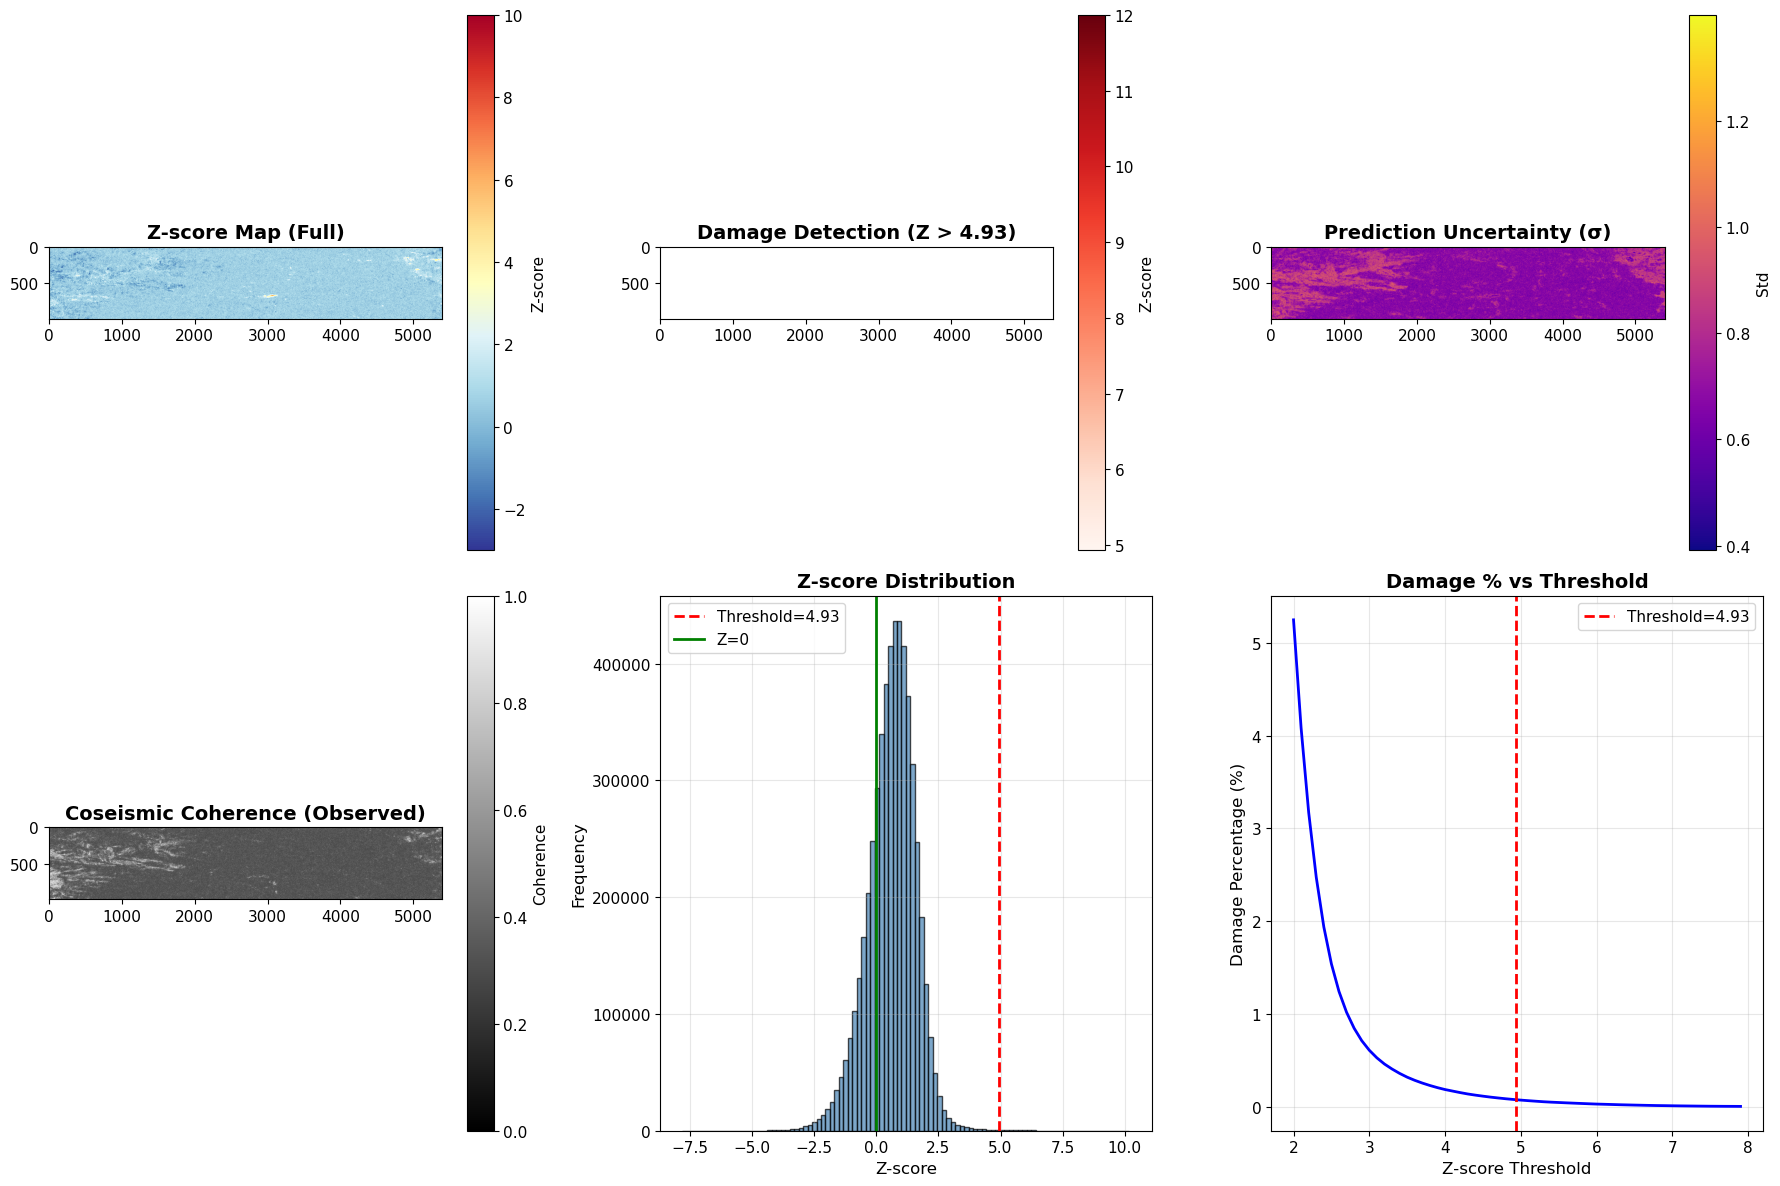

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

z_scores = results['z_scores']
threshold = 4.93

# 1. Z-score完整地图
im1 = axes[0, 0].imshow(z_scores, cmap='RdYlBu_r', vmin=-3, vmax=10)
axes[0, 0].set_title('Z-score Map (Full)', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0, 0], label='Z-score')

# 2. 损害检测 (Z > 4.93)
damage_mask = z_scores > threshold
masked_z = z_scores.copy()
masked_z[~damage_mask] = np.nan
im2 = axes[0, 1].imshow(masked_z, cmap='Reds', vmin=threshold, vmax=12)
axes[0, 1].set_title(f'Damage Detection (Z > {threshold})', fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[0, 1], label='Z-score')

# 3. 预测不确定性
im3 = axes[0, 2].imshow(results['pred_stds'], cmap='plasma')
axes[0, 2].set_title('Prediction Uncertainty (σ)', fontsize=14, fontweight='bold')
plt.colorbar(im3, ax=axes[0, 2], label='Std')

# 4. 同震观测
im4 = axes[1, 0].imshow(results['coseismic_observed'], cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title('Coseismic Coherence (Observed)', fontsize=14, fontweight='bold')
plt.colorbar(im4, ax=axes[1, 0], label='Coherence')

# 5. Z-score直方图
valid_z = z_scores[np.isfinite(z_scores)].flatten()
axes[1, 1].hist(valid_z, bins=100, alpha=0.7, color='steelblue', edgecolor='black')
axes[1, 1].axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={threshold}')
axes[1, 1].axvline(x=0, color='green', linestyle='-', linewidth=2, label='Z=0')
axes[1, 1].set_xlabel('Z-score', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Z-score Distribution', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. 多阈值损害百分比
thresholds = np.arange(2, 8, 0.1)
damage_pcts = [(valid_z > t).sum() / len(valid_z) * 100 for t in thresholds]

axes[1, 2].plot(thresholds, damage_pcts, 'b-', linewidth=2)
axes[1, 2].axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={threshold}')
axes[1, 2].set_xlabel('Z-score Threshold', fontsize=12)
axes[1, 2].set_ylabel('Damage Percentage (%)', fontsize=12)
axes[1, 2].set_title('Damage % vs Threshold', fontsize=14, fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config['output_dir']}/zscore_results.png", dpi=200, bbox_inches='tight')
plt.show()

### 6.4 Z-score分布分析

KeyboardInterrupt: 

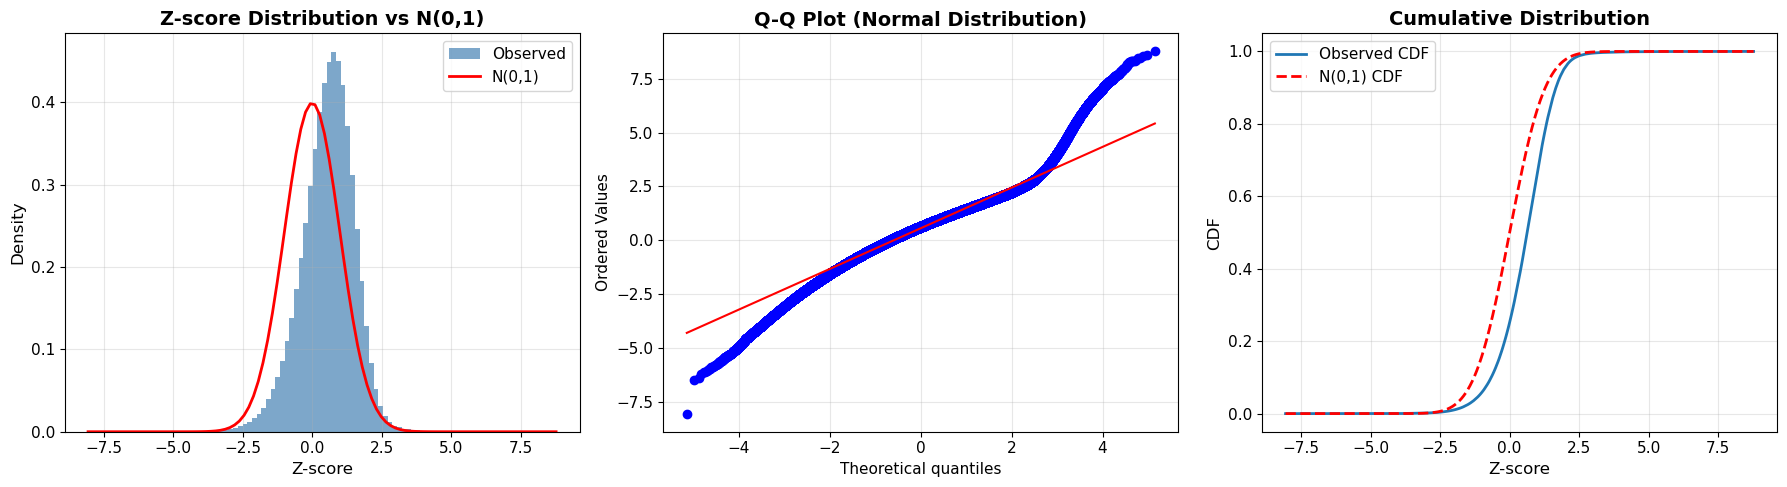

: 

: 

: 

: 

: 

In [ ]:
# Z-score分布分析
z_flat = results['z_scores'].flatten()
z_flat = z_flat[np.isfinite(z_flat)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 直方图 vs 标准正态分布
axes[0].hist(z_flat, bins=100, density=True, alpha=0.7, color='steelblue', label='Observed')

x = np.linspace(z_flat.min(), z_flat.max(), 100)
axes[0].plot(x, stats.norm.pdf(x, 0, 1), 'r-', linewidth=2, label='N(0,1)')

axes[0].set_xlabel('Z-score', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Z-score Distribution vs N(0,1)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2. Q-Q图
stats.probplot(z_flat, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normal Distribution)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 3. 累积分布函数
sorted_z = np.sort(z_flat)
cdf = np.arange(1, len(sorted_z) + 1) / len(sorted_z)
axes[2].plot(sorted_z, cdf, label='Observed CDF', linewidth=2)
axes[2].plot(sorted_z, stats.norm.cdf(sorted_z), 'r--', label='N(0,1) CDF', linewidth=2)
axes[2].set_xlabel('Z-score', fontsize=12)
axes[2].set_ylabel('CDF', fontsize=12)
axes[2].set_title('Cumulative Distribution', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config['output_dir']}/zscore_distribution_analysis.png", dpi=200, bbox_inches='tight')
plt.show()

# 统计检验
print(f"\nZ-score统计分析:")
print(f"  均值: {z_flat.mean():.4f} (理想值: 0)")
print(f"  标准差: {z_flat.std():.4f} (理想值: 1)")
print(f"  偏度: {stats.skew(z_flat):.4f}")
print(f"  峰度: {stats.kurtosis(z_flat):.4f}")

## 7. 保存结果

In [17]:
print(f"\n{'='*60}")
print("保存结果")
print(f"{'='*60}")

output_dir = Path(config['output_dir'])

# 保存Z-score地图 (转换为float32)
z_scores_float32 = results['z_scores'].astype(np.float32)
np.save(output_dir / 'zscore_map.npy', z_scores_float32)
print(f"✓ Z-score地图: {output_dir / 'zscore_map.npy'}")
print(f"  形状: {results['z_scores'].shape}, 数据类型: {z_scores_float32.dtype}")

# 保存预测均值 (转换为float32)
pred_means_float32 = results['pred_means'].astype(np.float32)
np.save(output_dir / 'pred_mean_map.npy', pred_means_float32)
print(f"✓ 预测均值地图: {output_dir / 'pred_mean_map.npy'}")

# 保存预测标准差 (转换为float32)
pred_stds_float32 = results['pred_stds'].astype(np.float32)
np.save(output_dir / 'pred_std_map.npy', pred_stds_float32)
print(f"✓ 预测标准差地图: {output_dir / 'pred_std_map.npy'}")

# 保存损害掩码 (多个阈值)
for thresh in [4.0, 4.93, 5.0, 6.0]:
    mask = results['z_scores'] > thresh
    mask_path = output_dir / f'damage_mask_zscore_{thresh:.2f}.npy'
    # 掩码可以保存为bool类型以节省空间
    np.save(mask_path, mask.astype(bool))
    count = mask.sum()
    print(f"✓ 损害掩码 (Z>{thresh}): {count:,} 像素 ({count/mask.size*100:.2f}%)")

# 保存完整结果 (所有数据都转换为float32)
np.savez_compressed(
    output_dir / 'full_results.npz',
    z_scores=results['z_scores'].astype(np.float32),
    pred_means=results['pred_means'].astype(np.float32),
    pred_stds=results['pred_stds'].astype(np.float32),
    coseismic_observed=results['coseismic_observed'].astype(np.float32) if 'coseismic_observed' in results else None
)
print(f"✓ 完整结果: {output_dir / 'full_results.npz'}")

# 保存训练历史
with open(output_dir / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=4)
print(f"✓ 训练历史: {output_dir / 'training_history.json'}")

# 保存配置
with open(output_dir / 'config.json', 'w') as f:
    json.dump(config, f, indent=4)
print(f"✓ 配置文件: {output_dir / 'config.json'}")

print(f"\n所有结果已保存到: {output_dir}")
print(f"{'='*60}")


保存结果
✓ Z-score地图: masked_diagonal_vit_12x12_results/zscore_map.npy
  形状: (990, 5400), 数据类型: float32
✓ 预测均值地图: masked_diagonal_vit_12x12_results/pred_mean_map.npy
✓ 预测标准差地图: masked_diagonal_vit_12x12_results/pred_std_map.npy
✓ 损害掩码 (Z>4.0): 9,813 像素 (0.18%)
✓ 损害掩码 (Z>4.93): 3,985 像素 (0.07%)
✓ 损害掩码 (Z>5.0): 3,726 像素 (0.07%)
✓ 损害掩码 (Z>6.0): 1,443 像素 (0.03%)


✓ 完整结果: masked_diagonal_vit_12x12_results/full_results.npz


NameError: name 'history' is not defined

In [20]:
import numpy as np
import os
import subprocess
from mintpy.utils.writefile import write_isce_file

# 基础目录路径
base_dir = "/scratch/yangyanchen/amatrice2025/vitmask20260114/masked_diagonal_vit_12x12_20260117results/"

# 获取所有_score.npy文件
score_files = [f for f in os.listdir(base_dir) 
              if f.endswith("_map.npy") and os.path.isfile(os.path.join(base_dir, f))]

# 经纬度文件路径
lat_file = os.path.join("/scratch/yangyanchen/amatrice2025/yunjun/", "lat_cropped.rdr")
lon_file = os.path.join("/scratch/yangyanchen/amatrice2025/yunjun/", "lon_cropped.rdr")

# 子集提取参数
subset_params = "-l 42.6 42.7 -L 13.2 13.4"

# 循环处理每个score文件
for score_file in score_files:
    try:
        # 1. 加载npy数据
        file_path = os.path.join(base_dir, score_file)
        print(f"处理文件: {score_file}")
        data = np.load(file_path)
        
        # 2. 创建输出文件名基础
        base_name = score_file.replace("_map.npy", "")
        
        # 3. 写入ISCE格式
        cor_file = os.path.join(base_dir, f"{base_name}.cor")
        write_isce_file(
            data=data,
            out_file=cor_file,
            file_type='isce_cor'
        )
        print(f"  ISCE文件已创建: {cor_file}")
        
        # 4. 地理编码
        geo_cor_file = os.path.join(base_dir, f"geo_{base_name}.cor")
        geocode_cmd = f"geocode.py {cor_file} --lat-file {lat_file} --lon-file {lon_file} --outdir {base_dir}"
        subprocess.run(geocode_cmd, shell=True, check=True)
        print(f"  地理编码完成: {geo_cor_file}")
        
        # 5. 子集提取
        subset_cor_file = os.path.join(base_dir, f"{base_name}final.cor")
        subset_cmd = f"subset.py {geo_cor_file} {subset_params} --output {subset_cor_file}"
        subprocess.run(subset_cmd, shell=True, check=True)
        print(f"  子集提取完成: {subset_cor_file}")
        
        # 6. 保存为GeoTIFF
        tif_file = os.path.join(base_dir, f"{base_name}final.tif")
        gdal_cmd = f"save_gdal.py {subset_cor_file} --output {tif_file}"
        subprocess.run(gdal_cmd, shell=True, check=True)
        print(f"  GeoTIFF已生成: {tif_file}")
        
        print(f"文件 {score_file} 处理完成!\n")
    
    except Exception as e:
        print(f"处理文件 {score_file} 时出错: {str(e)}")
        continue

print("所有文件处理完成!")

处理文件: zscore_map.npy
write file: /scratch/yangyanchen/amatrice2025/vitmask20260114/masked_diagonal_vit_12x12_20260117results/zscore.cor
write file: /scratch/yangyanchen/amatrice2025/vitmask20260114/masked_diagonal_vit_12x12_20260117results/zscore.cor.xml
write file: /scratch/yangyanchen/amatrice2025/vitmask20260114/masked_diagonal_vit_12x12_20260117results/zscore.cor.vrt
  ISCE文件已创建: /scratch/yangyanchen/amatrice2025/vitmask20260114/masked_diagonal_vit_12x12_20260117results/zscore.cor
number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: /scratch/yangyanchen/amatrice2025/yunjun/lat_cropped.rdr
calculate output pixel size using approach 1 (same pixel area before/after resampling)
calculate output pixel size using approach 2 (same matrix shape before/after resampling)
output pixel size in (lat, lon) in degree: (-0.00015194375064182572, 4.855383985858203e-05)
output area extent in (S, N, W, E) in degree: (42.57485231181608, 42.

/home/yangyanchen/tools/miniforge/envs/isce_env/lib/python3.8/site-packages/mintpy/save_gdal.py:57: UserWarning: No EPSG or UTM_ZONE metadata found! Assume EPSG = 4326 (WGS84) and continue.
  warnings.warn(msg)


initiate GDAL driver: GeoTIFF
create raster band:
  raster row / column number: 658, 4119
  raster data type: 6 (float32)
set transform info: (13.199982290732505, 4.855383985858203e-05, 0, 42.700053962344946, 0, -0.00015194375064182572)
set projection as: EPSG 4326
write data to raster band
finished writing to /scratch/yangyanchen/amatrice2025/vitmask20260114/masked_diagonal_vit_12x12_20260117results/zscorefinal.tif
  GeoTIFF已生成: /scratch/yangyanchen/amatrice2025/vitmask20260114/masked_diagonal_vit_12x12_20260117results/zscorefinal.tif
文件 zscore_map.npy 处理完成!

处理文件: pred_mean_map.npy
write file: /scratch/yangyanchen/amatrice2025/vitmask20260114/masked_diagonal_vit_12x12_20260117results/pred_mean.cor
write file: /scratch/yangyanchen/amatrice2025/vitmask20260114/masked_diagonal_vit_12x12_20260117results/pred_mean.cor.xml
write file: /scratch/yangyanchen/amatrice2025/vitmask20260114/masked_diagonal_vit_12x12_20260117results/pred_mean.cor.vrt
  ISCE文件已创建: /scratch/yangyanchen/amatrice2025/

/home/yangyanchen/tools/miniforge/envs/isce_env/lib/python3.8/site-packages/mintpy/save_gdal.py:57: UserWarning: No EPSG or UTM_ZONE metadata found! Assume EPSG = 4326 (WGS84) and continue.
  warnings.warn(msg)


  GeoTIFF已生成: /scratch/yangyanchen/amatrice2025/vitmask20260114/masked_diagonal_vit_12x12_20260117results/pred_meanfinal.tif
文件 pred_mean_map.npy 处理完成!

处理文件: pred_std_map.npy
write file: /scratch/yangyanchen/amatrice2025/vitmask20260114/masked_diagonal_vit_12x12_20260117results/pred_std.cor
write file: /scratch/yangyanchen/amatrice2025/vitmask20260114/masked_diagonal_vit_12x12_20260117results/pred_std.cor.xml
write file: /scratch/yangyanchen/amatrice2025/vitmask20260114/masked_diagonal_vit_12x12_20260117results/pred_std.cor.vrt
  ISCE文件已创建: /scratch/yangyanchen/amatrice2025/vitmask20260114/masked_diagonal_vit_12x12_20260117results/pred_std.cor
number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: /scratch/yangyanchen/amatrice2025/yunjun/lat_cropped.rdr
calculate output pixel size using approach 1 (same pixel area before/after resampling)
calculate output pixel size using approach 2 (same matrix shape before/after resampling

/home/yangyanchen/tools/miniforge/envs/isce_env/lib/python3.8/site-packages/mintpy/save_gdal.py:57: UserWarning: No EPSG or UTM_ZONE metadata found! Assume EPSG = 4326 (WGS84) and continue.
  warnings.warn(msg)


  GeoTIFF已生成: /scratch/yangyanchen/amatrice2025/vitmask20260114/masked_diagonal_vit_12x12_20260117results/pred_stdfinal.tif
文件 pred_std_map.npy 处理完成!

所有文件处理完成!


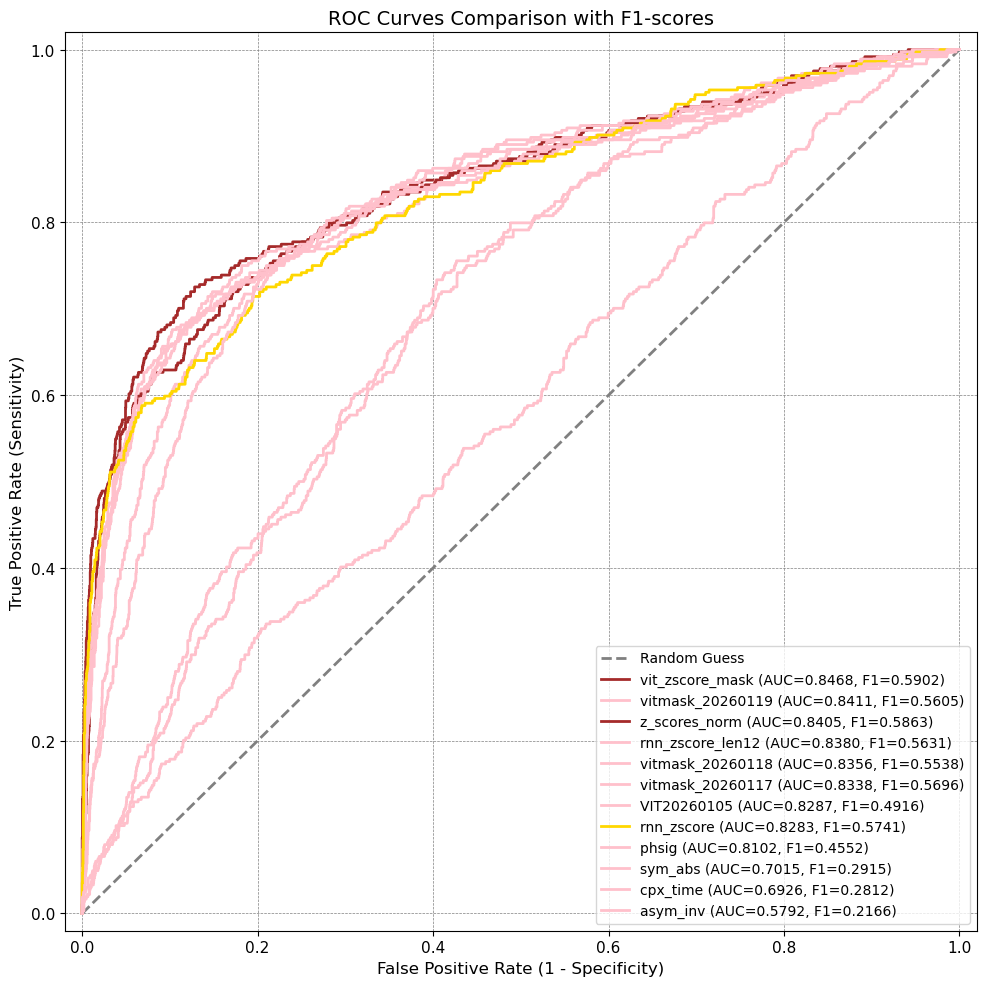


特征性能报告:
按AUC值降序排列，显示最佳F1-score及对应的阈值和虚警率(FPR)
----------------------------------------------------------------------------------------------------
特征名称         AUC值         最佳F1-score      阈值              虚警率(FPR)       
----------------------------------------------------------------------------------------------------
vit_zscore_mask 0.84680      0.59016         3.31149         0.04969        
vitmask_20260119 0.84113      0.56053         2.98229         0.05982        
z_scores_norm 0.84052      0.58626         0.58788         0.01896        
rnn_zscore_len12 0.83796      0.56313         2.51428         0.04282        
vitmask_20260118 0.83556      0.55381         3.19825         0.06113        
vitmask_20260117 0.83379      0.56960         3.09685         0.06407        
VIT20260105  0.82870      0.49161         0.29262         0.08663        
rnn_zscore   0.82829      0.57407         2.16880         0.03204        
phsig        0.81019      0.45522         0.34946         0.12063

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, f1_score, confusion_matrix

df = pd.read_csv("/scratch/yangyanchen/amatrice2025/roc精度评价VIT.csv")  # 替换为你的文件路径

# 定义特征列表和颜色配置 decorrelation	TGRS_std	TGRS

features = [
    ("z_scores_norm", "brown"),
    ("vit_zscore_mask", "brown"),
    ("phsig", "pink"),
    ("vitmask_20260117", "pink"),
        ("vitmask_20260118", "pink"),
            ("vitmask_20260119", "pink"),
    ("cpx_time", "pink"),
        ("sym_abs", "pink"),
            ("asym_inv", "pink"),
    ("rnn_zscore_len12", "pink"),
    ("VIT20260105", "pink"),
    ("rnn_zscore", "gold")
    
]

# 设置画布
plt.figure(figsize=(10, 10))

# 绘制参考线
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--', label='Random Guess')

# 创建列表存储计算结果
roc_data = []
f1_results = []  # 存储F1-score结果

# 先计算所有特征的AUC值和F1-score
for feature, color in features:
    y_true = df['damaged']
    y_score = df[feature]
    
    # 计算ROC曲线
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    # 找到最佳F1-score及其阈值
    best_f1 = 0
    best_threshold = 0
    best_fpr = 0
    best_f1_index = 0
    
    # 遍历所有阈值计算F1-score
    for i, threshold in enumerate(thresholds):
        # 使用当前阈值进行预测
        y_pred = (y_score >= threshold).astype(int)
        
        # 计算F1-score
        f1 = f1_score(y_true, y_pred)
        
        # 更新最佳F1-score
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_f1_index = i
    
    # 获取最佳阈值对应的虚警率(FPR)
    if best_f1_index < len(fpr):
        best_fpr = fpr[best_f1_index]
    else:
        # 如果索引越界，使用上一个可用的FPR值
        best_fpr = fpr[-1] if fpr.size > 0 else 0
    
    # 存储特征名、颜色、AUC值以及ROC曲线数据
    roc_data.append({
        'feature': feature,
        'color': color,
        'auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'best_f1': best_f1,
        'best_threshold': best_threshold,
        'best_fpr': best_fpr
    })
    
    # 存储F1结果用于后续输出
    f1_results.append({
        'feature': feature,
        'auc': roc_auc,
        'best_f1': best_f1,
        'threshold': best_threshold,
        'fpr': best_fpr
    })

# 按AUC值从高到低排序
roc_data_sorted = sorted(roc_data, key=lambda x: x['auc'], reverse=True)

# 按排序后的顺序绘制ROC曲线
for data in roc_data_sorted:
    plt.plot(data['fpr'], data['tpr'], color=data['color'], lw=2,
             label=f"{data['feature']} (AUC={data['auc']:.4f}, F1={data['best_f1']:.4f})")

# 图表装饰
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves Comparison with F1-scores', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', color='gray', linewidth=0.5)
plt.tight_layout()
plt.savefig('ROC_curves_with_F1_scores.png', dpi=300)
plt.show()

# 打印F1-score和虚警率结果
print("\n特征性能报告:")
print("按AUC值降序排列，显示最佳F1-score及对应的阈值和虚警率(FPR)")
print("-" * 100)
print("{:<12} {:<12} {:<15} {:<15} {:<15}".format(
    '特征名称', 'AUC值', '最佳F1-score', '阈值', '虚警率(FPR)'))
print("-" * 100)

# 按AUC排序F1结果
f1_results_sorted = sorted(f1_results, key=lambda x: x['auc'], reverse=True)

for result in f1_results_sorted:
    print("{:<12} {:<12.5f} {:<15.5f} {:<15.5f} {:<15.5f}".format(
        result['feature'], 
        result['auc'], 
        result['best_f1'], 
        result['threshold'], 
        result['fpr']))

# 按F1-score排序
f1_results_sorted_by_f1 = sorted(f1_results, key=lambda x: x['best_f1'], reverse=True)

print("\n按F1-score排序:")
print("-" * 100)
print("{:<12} {:<12} {:<15} {:<15} {:<15}".format(
    '特征名称', 'AUC值', '最佳F1-score', '阈值', '虚警率(FPR)'))
print("-" * 100)

for result in f1_results_sorted_by_f1:
    print("{:<12} {:<12.5f} {:<15.5f} {:<15.5f} {:<15.5f}".format(
        result['feature'], 
        result['auc'], 
        result['best_f1'], 
        result['threshold'], 
        result['fpr']))
# 按虚警率(FPR)排序（升序，即FPR越小越好）
f1_results_sorted_by_fpr = sorted(f1_results, key=lambda x: x['fpr'])

print("\n按虚警率(FPR)排序（从小到大）:")
print("-" * 100)
print("{:<12} {:<12} {:<15} {:<15} {:<15}".format(
    '特征名称', 'AUC值', '最佳F1-score', '阈值', '虚警率(FPR)'))
print("-" * 100)

for result in f1_results_sorted_by_fpr:
    print("{:<12} {:<12.5f} {:<15.5f} {:<15.5f} {:<15.5f}".format(
        result['feature'], 
        result['auc'], 
        result['best_f1'], 
        result['threshold'], 
        result['fpr']))


## 8. 总结

### 方法概述

本方法实现了基于遮蔽对角线预测的自监督Vision Transformer (12×12矩阵)，用于SAR相干性矩阵的损害评估：

1. **自监督策略**
   - 遮蔽12×12相干性矩阵对角线的某个元素
   - 训练模型预测被遮蔽的值
   - 模型学会从矩阵整体信息推断对角线元素

2. **高斯分布预测**
   - 模型输出 (μ, σ) 而非单一值
   - 量化预测的不确定性
   - 使用高斯负对数似然损失训练

3. **Z-score损害评估**
   - Z = (预测μ - 观测值) / σ
   - 正Z-score表示相干性下降，可能损害
   - Z > 4.93 作为损害阈值

### 12×12矩阵配置

| 参数 | 值 | 说明 |
|------|-----|------|
| 矩阵尺寸 | 12×12 | 相干性矩阵 |
| Patch尺寸 | 3×3 | 12 = 3 × 4 |
| Patch数量 | 16 | 4×4 patches |
| 对角线长度 | 12 | d₀ 到 d₁₁ |
| 遮蔽位置 | [7,8,9,10,11] | 后5个位置 |
| 预测目标 | d₁₂ | 同震相邻相干性 |

In [ ]:
print(f"\n{'='*70}")
print("🎉 遮蔽对角线自监督ViT损害评估完成! (12×12) 🎉")
print(f"{'='*70}")
print(f"\n关键结果:")
print(f"  - 矩阵尺寸: 12×12")
print(f"  - 最佳验证损失: {best_val_loss:.6f}")
print(f"  - 输出形状: {results['z_scores'].shape}")
print(f"  - Z-score范围: [{results['z_scores'].min():.2f}, {results['z_scores'].max():.2f}]")
print(f"  - 损害像素 (Z>4.93): {(results['z_scores'] > 4.93).sum():,}")
print(f"  - 结果保存目录: {config['output_dir']}")
print(f"{'='*70}")

check_memory_usage()

: 

: 

: 

: 

: 